In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
# Carregando o dataset
df = pd.read_csv('../data/vendas_desafio.csv', sep=',')
df.head(5)

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS


In [4]:
# Corrigindo as siglas dos estados com base nas cidades
df.loc[df['cidade'] == 'São Paulo', 'estado'] = 'SP'
df.loc[df['cidade'] == 'Rio de Janeiro', 'estado'] = 'RJ'
df.loc[df['cidade'] == 'Belo Horizonte', 'estado'] = 'MG'
df.loc[df['cidade'] == 'Curitiba', 'estado'] = 'PR'
df.loc[df['cidade'] == 'Porto Alegre', 'estado'] = 'RS'
df.head(5)

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,MG
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,SP
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,PR
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,SP


In [5]:
# Adicionando coluna valor_venda
df['valor_venda'] = round(df['quantidade'] * df['preco_unitario'], 2)
df.head(5)

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado,valor_venda
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,MG,254.22
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,SP,2851.02
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,PR,237.39
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ,10414.41
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,SP,833.28


In [6]:
# Agrupamento de valor_venda por produto
df.groupby('produto')['valor_venda'].sum().reset_index().sort_values(by='valor_venda', ascending=False)

,produto,valor_venda
8,Notebook,8290852.39
4,Mesa,3092939.21
6,Monitor,2364641.86
0,Cadeira,1629832.30
1,Fone,495633.09
5,Mochila,460376.91
9,Teclado,384771.59
2,Livro Python,296630.22
3,Livro SQL,247460.70
7,Mouse,205764.16


In [7]:
# Agrupamento de valor_venda por categoria
df.groupby('categoria')['valor_venda'].sum().reset_index().sort_values(by='valor_venda', ascending=False)

,categoria,valor_venda
1,Eletrônicos,11741663.09
3,Móveis,4722771.51
2,Livros,544090.92
0,Acessórios,460376.91


In [8]:
# Agrupamento de valor_venda por cliente
df.groupby('cliente')['valor_venda'].sum().reset_index().sort_values(by='valor_venda', ascending=False)

,cliente,valor_venda
210,Mathias,122641.69
32,Asafe,121077.15
177,Lunna,111178.92
57,Carlos Eduardo,110931.92
263,Thiago,107474.24
...,...,...
186,Marcos Vinicius,24779.10
105,Guilherme,24450.71
30,Arthur Gabriel,24413.17
206,Mariane,22230.06


C:\Users\gr556\AppData\Local\Temp\ipykernel_19068\3519060031.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


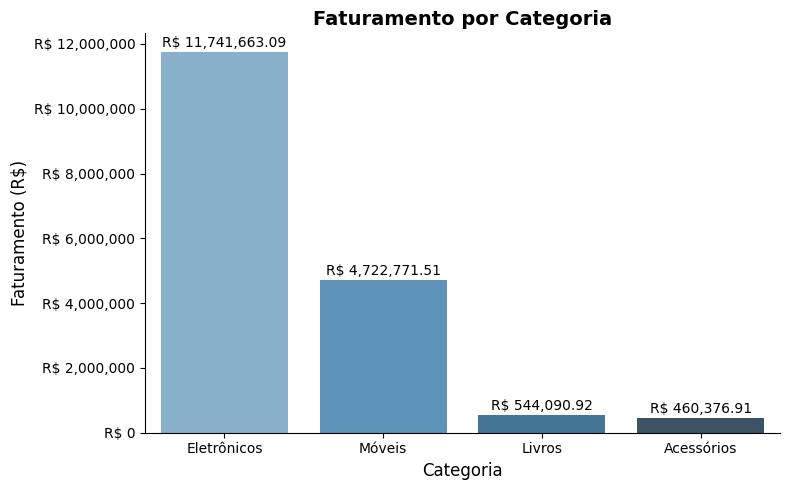

In [9]:
#Criando grafico de faturamento por produto
faturamento_categoria = (
    df.groupby('categoria')['valor_venda'].sum().reset_index().sort_values(by='valor_venda', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=faturamento_categoria,
    x='categoria',
    y='valor_venda',
    palette='Blues_d',
    ax=ax
)

ax.set_title('Faturamento por Categoria', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoria', fontsize=12)
ax.set_ylabel('Faturamento (R$)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

# Formatando as barras
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 60000,
        f'R$ {bar.get_height():,.2f}',
        ha='center', va='bottom', fontsize=10
    )

sns.despine()
plt.tight_layout()
plt.show()


In [10]:
# Criando tabela resumo de vendas por produto e categoria
resumo_vendas = df.groupby(['produto', 'categoria'])[['quantidade', 'valor_venda']].sum().reset_index()
resumo_vendas = resumo_vendas.sort_values('valor_venda', ascending=False)
display(resumo_vendas)

,produto,categoria,quantidade,valor_venda
8,Notebook,Eletrônicos,2364,8290852.39
4,Mesa,Móveis,2581,3092939.21
6,Monitor,Eletrônicos,2613,2364641.86
0,Cadeira,Móveis,2319,1629832.30
1,Fone,Eletrônicos,2469,495633.09
5,Mochila,Acessórios,2557,460376.91
9,Teclado,Eletrônicos,2566,384771.59
2,Livro Python,Livros,2470,296630.22
3,Livro SQL,Livros,2474,247460.70
7,Mouse,Eletrônicos,2581,205764.16


In [ ]:
# Exportando os dados resumo_vendas e vendas_normalizadas em CSV
resumo_vendas.to_csv('../data/resumo_vendas.csv', index=False, sep=';', decimal=',')
vendas_normalizadas = df.copy()
vendas_normalizadas.to_csv('../data/vendas_normalizadas.csv', index=False, sep=';', decimal=',')

In [ ]:
# qual categoria vendeu mais em quantidade?
resumo_vendas.groupby('categoria')['quantidade'].sum().reset_index().sort_values(by='quantidade', ascending=False)

,categoria,quantidade
1,Eletrônicos,12593
2,Livros,4944
3,Móveis,4900
0,Acessórios,2557


In [ ]:
# Qual produto vendeu mais em quantidade?
df.groupby('produto')['quantidade'].count().reset_index().sort_values(by='quantidade', ascending=False)

,produto,quantidade
6,Monitor,1045
5,Mochila,1037
7,Mouse,1036
4,Mesa,1023
9,Teclado,1007
2,Livro Python,1005
3,Livro SQL,987
1,Fone,973
8,Notebook,963
0,Cadeira,924


In [ ]:
# Qual vendedor vendeu mais em quantidade de vendas e quantidade de valor.
df.groupby('vendedor').agg(qtd_vendas = ('id_venda', 'count'),
                            valor_total = ('valor_venda', 'sum')).reset_index().sort_values(by='qtd_vendas', ascending=False)

,vendedor,qtd_vendas,valor_total
3,Daniela,2053,3468356.62
1,Bruno,2036,3501930.96
4,Eduardo,1994,3477302.18
0,Ana,1982,3544588.45
2,Carlos,1935,3476724.22


In [ ]:
# Alterando o tipo da coluna para datetime
df['data_venda'] = pd.to_datetime(df['data_venda'])

# Extraindo o mes da venda
df['mes'] = df['data_venda'].dt.to_period('M')

# calculando o total de vendas por mes
vendas_por_mes = df.groupby('mes')['valor_venda'].sum().reset_index().sort_values(by='valor_venda', ascending=False)
display(vendas_por_mes)

,mes,valor_venda
3,2024-04,1571459.42
2,2024-03,1561420.22
8,2024-09,1560269.23
4,2024-05,1537043.09
7,2024-08,1531974.02
6,2024-07,1528937.90
10,2024-11,1436475.33
9,2024-10,1423821.79
1,2024-02,1414699.44
5,2024-06,1346568.09


In [ ]:
# existe cliente que comprou mais de 1 vez?
df.groupby('cliente').agg(qtd_compras = ('id_venda', 'count')
                          ).reset_index().sort_values(by='qtd_compras', ascending=False)

,cliente,qtd_compras
2,Alexandre,50
43,Benício,49
162,Luan,49
5,Allana,48
29,Arthur,48
...,...,...
80,Eduardo,24
211,Matteo,24
97,Fernando,23
30,Arthur Gabriel,23
